In [1]:
# import libraries for data work, modeling, and plots
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from xgboost import XGBRegressor

# resolve project root whether jupyter sets cwd to notebooks/ or to the project root
_cwd = Path().resolve()
PROJECT_DIR = _cwd if (_cwd / 'data').exists() else _cwd.parent
PROCESSED_DIR = PROJECT_DIR / 'data' / 'processed'
RESULTS_DIR = PROJECT_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print('Project dir:', PROJECT_DIR)
print('Processed dir:', PROCESSED_DIR)


Project dir: C:\Users\abdul\Documents\Toronto Bikeshare Forecasting
Processed dir: C:\Users\abdul\Documents\Toronto Bikeshare Forecasting\data\processed


In [2]:
# load the prepared train/validation/test splits
train = pd.read_csv(PROCESSED_DIR / 'train.csv', parse_dates=['hour'])
val = pd.read_csv(PROCESSED_DIR / 'val.csv', parse_dates=['hour'])
test = pd.read_csv(PROCESSED_DIR / 'test.csv', parse_dates=['hour'])

# build one feature set for linear regression and one for tree models
target = 'pickups'
linear_features = [c for c in train.columns if c not in ['cluster_id', 'hour', target]]
tree_features = [c for c in train.columns if c not in ['hour', target]]

# split inputs (X) from the target (y)
X_train_linear = train[linear_features]
X_val_linear = val[linear_features]
X_test_linear = test[linear_features]

X_train_tree = train[tree_features]
X_val_tree = val[tree_features]
X_test_tree = test[tree_features]

y_train = train[target].to_numpy()
y_val = val[target].to_numpy()
y_test = test[target].to_numpy()

metrics_rows = []
rf_search_rows = []
xgb_search_rows = []

print(train.shape, val.shape, test.shape)
print(tree_features)

(58176, 15) (5760, 15) (5376, 15)
['cluster_id', 'cluster_capacity', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'is_holiday', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'is_rainy', 'lag_24h']


## Linear Regression Baseline

In [3]:
# fit the original linear baseline for comparison
linear_model = LinearRegression()
linear_model.fit(X_train_linear, y_train)

# save train/validation/test metrics for the comparison table
for split_name, X_split, y_split in [
    ('train', X_train_linear, y_train),
    ('val', X_val_linear, y_val),
    ('test', X_test_linear, y_test),
]:
    pred = np.clip(linear_model.predict(X_split), 0, None)
    metrics_rows.append({
        'model': 'Linear Regression',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

linear_metrics = pd.DataFrame(metrics_rows)
linear_metrics = linear_metrics[linear_metrics['model'] == 'Linear Regression'].copy()
display(linear_metrics.round(4))


,model,split,MAE,RMSE,R2
0,Linear Regression,train,35.5078,100.6406,0.8920
1,Linear Regression,val,14.5886,44.5201,0.6794
2,Linear Regression,test,12.8033,34.6772,0.6780


## Random Forest Baseline and Tuning

In [4]:
# train a simple untuned random forest first
rf_baseline_params = {
    'n_estimators': 200,
    'max_depth': 16,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1,
}

rf_baseline = RandomForestRegressor(**rf_baseline_params)
rf_baseline.fit(X_train_tree, y_train)

# record baseline metrics on all three splits
for split_name, X_split, y_split in [
    ('train', X_train_tree, y_train),
    ('val', X_val_tree, y_val),
    ('test', X_test_tree, y_test),
]:
    pred = np.clip(rf_baseline.predict(X_split), 0, None)
    metrics_rows.append({
        'model': 'Random Forest (baseline)',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

display(pd.DataFrame(metrics_rows).query("model == 'Random Forest (baseline)'").round(4))

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [12, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1],
    'max_features': ['sqrt'],
}

best_rf_params = None
best_rf_val_rmse = float('inf')

# try each parameter combination and keep the best validation RMSE
for params in ParameterGrid(rf_param_grid):
    model = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    model.fit(X_train_tree, y_train)

    val_pred = np.clip(model.predict(X_val_tree), 0, None)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    rf_search_rows.append({'model_family': 'Random Forest', **params, 'val_RMSE': val_rmse})

    if val_rmse < best_rf_val_rmse:
        best_rf_val_rmse = val_rmse
        best_rf_params = params.copy()

rf_history = pd.DataFrame(rf_search_rows).sort_values('val_RMSE').reset_index(drop=True)
print('Best Random Forest params:')
print(best_rf_params)

# refit the best random forest and save its metrics
rf_tuned = RandomForestRegressor(random_state=42, n_jobs=-1, **best_rf_params)
rf_tuned.fit(X_train_tree, y_train)

rf_tuned_test_pred = None
for split_name, X_split, y_split in [
    ('train', X_train_tree, y_train),
    ('val', X_val_tree, y_val),
    ('test', X_test_tree, y_test),
]:
    pred = np.clip(rf_tuned.predict(X_split), 0, None)
    if split_name == 'test':
        rf_tuned_test_pred = pred
    metrics_rows.append({
        'model': 'Random Forest (tuned)',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

display(pd.DataFrame(metrics_rows).query("model == 'Random Forest (tuned)'").round(4))


,model,split,MAE,RMSE,R2
3,Random Forest (baseline),train,9.9332,26.5353,0.9925
4,Random Forest (baseline),val,10.1010,33.9519,0.8135
5,Random Forest (baseline),test,7.4129,23.0807,0.8574


Best Random Forest params:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


,model,split,MAE,RMSE,R2
6,Random Forest (tuned),train,7.2188,20.8990,0.9953
7,Random Forest (tuned),val,10.0172,33.9738,0.8133
8,Random Forest (tuned),test,7.2881,22.5058,0.8644


## XGBoost Baseline and Tuning

In [5]:
# train a simple untuned XGBoost model first
xgb_tuned_test_pred = None
best_xgb_params = None

xgb_baseline_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 1,
    'objective': 'reg:squarederror',
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
}

xgb_baseline = XGBRegressor(**xgb_baseline_params)
xgb_baseline.fit(X_train_tree, y_train)

# record baseline metrics on all three splits
for split_name, X_split, y_split in [
    ('train', X_train_tree, y_train),
    ('val', X_val_tree, y_val),
    ('test', X_test_tree, y_test),
]:
    pred = np.clip(xgb_baseline.predict(X_split), 0, None)
    metrics_rows.append({
        'model': 'XGBoost (baseline)',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

display(pd.DataFrame(metrics_rows).query("model == 'XGBoost (baseline)'").round(4))

xgb_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [1],
}

best_xgb_val_rmse = float('inf')

# try each parameter combination and keep the best validation RMSE
for params in ParameterGrid(xgb_param_grid):
    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        **params,
    )
    model.fit(X_train_tree, y_train)

    val_pred = np.clip(model.predict(X_val_tree), 0, None)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))

    xgb_search_rows.append({'model_family': 'XGBoost', **params, 'val_RMSE': val_rmse})

    if val_rmse < best_xgb_val_rmse:
        best_xgb_val_rmse = val_rmse
        best_xgb_params = params.copy()

xgb_history = pd.DataFrame(xgb_search_rows).sort_values('val_RMSE').reset_index(drop=True)
print('Best XGBoost params:')
print(best_xgb_params)

# refit the best XGBoost model and save its metrics
xgb_tuned = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
    **best_xgb_params,
)
xgb_tuned.fit(X_train_tree, y_train)

for split_name, X_split, y_split in [
    ('train', X_train_tree, y_train),
    ('val', X_val_tree, y_val),
    ('test', X_test_tree, y_test),
]:
    pred = np.clip(xgb_tuned.predict(X_split), 0, None)
    if split_name == 'test':
        xgb_tuned_test_pred = pred
    metrics_rows.append({
        'model': 'XGBoost (tuned)',
        'split': split_name,
        'MAE': mean_absolute_error(y_split, pred),
        'RMSE': np.sqrt(mean_squared_error(y_split, pred)),
        'R2': r2_score(y_split, pred),
    })

display(pd.DataFrame(metrics_rows).query("model == 'XGBoost (tuned)'").round(4))


,model,split,MAE,RMSE,R2
9,XGBoost (baseline),train,14.3532,35.3031,0.9867
10,XGBoost (baseline),val,8.9883,30.7822,0.8467
11,XGBoost (baseline),test,7.5056,22.2101,0.8679


Best XGBoost params:
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 0.8}


,model,split,MAE,RMSE,R2
12,XGBoost (tuned),train,12.2631,29.1531,0.9909
13,XGBoost (tuned),val,8.8449,30.4567,0.8500
14,XGBoost (tuned),test,7.0364,21.1831,0.8799


## Compare and Save Results

MAE                        R2                  \
split                        test    train      val    test   train     val   
model                                                                         
Linear Regression         12.8033  35.5078  14.5886  0.6780  0.8920  0.6794   
Random Forest (baseline)   7.4129   9.9332  10.1010  0.8574  0.9925  0.8135   
Random Forest (tuned)      7.2881   7.2188  10.0172  0.8644  0.9953  0.8133   
XGBoost (baseline)         7.5056  14.3532   8.9883  0.8679  0.9867  0.8467   
XGBoost (tuned)            7.0364  12.2631   8.8449  0.8799  0.9909  0.8500   

                             RMSE                     
split                        test     train      val  
model                                                 
Linear Regression         34.6772  100.6406  44.5201  
Random Forest (baseline)  23.0807   26.5353  33.9519  
Random Forest (tuned)     22.5058   20.8990  33.9738  
XGBoost (baseline)        22.2101   35.3031  30.7822  
XGBoost (tuned)           21.1831   29.1531  30.4567

Best validation model: XGBoost (tuned)
Best test model: XGBoost (tuned)


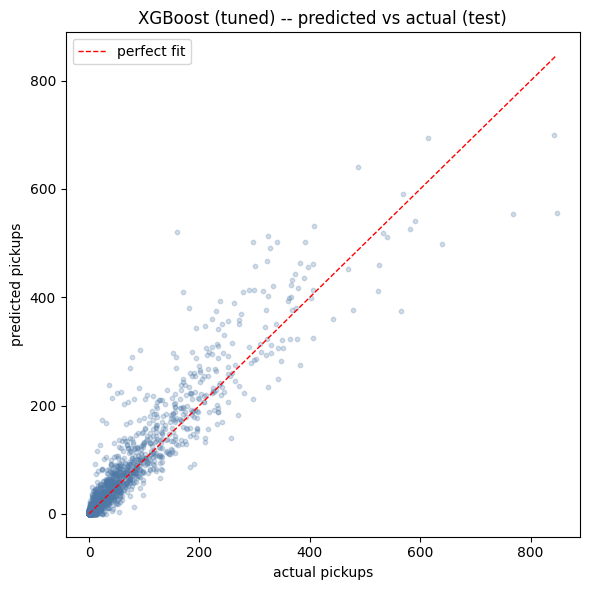

Saved results to the results folder


In [6]:
# combine all model metrics into one comparison table
metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df.pivot_table(index='model', columns='split', values=['MAE', 'RMSE', 'R2']).round(4))

best_val_model = metrics_df[metrics_df['split'] == 'val'].sort_values('RMSE').iloc[0]['model']
best_test_model = metrics_df[metrics_df['split'] == 'test'].sort_values('RMSE').iloc[0]['model']

print('Best validation model:', best_val_model)
print('Best test model:', best_test_model)

# save metrics, tuning history, and best parameter choices
metrics_df.to_csv(RESULTS_DIR / 'tree_model_metrics.csv', index=False)

search_history_df = pd.concat([
    pd.DataFrame(rf_search_rows).assign(search='random_forest'),
    pd.DataFrame(xgb_search_rows).assign(search='xgboost'),
], ignore_index=True)
search_history_df.to_csv(RESULTS_DIR / 'tree_model_search_history.csv', index=False)

with open(RESULTS_DIR / 'tree_model_best_params.json', 'w') as f:
    json.dump({'random_forest': best_rf_params, 'xgboost': best_xgb_params}, f, indent=2)

# choose the better tuned tree model using validation RMSE
rf_val_rmse = metrics_df[(metrics_df['model'] == 'Random Forest (tuned)') & (metrics_df['split'] == 'val')]['RMSE'].iloc[0]
xgb_val_rmse = metrics_df[(metrics_df['model'] == 'XGBoost (tuned)') & (metrics_df['split'] == 'val')]['RMSE'].iloc[0]

if xgb_val_rmse < rf_val_rmse:
    best_tree_name = 'XGBoost (tuned)'
    best_tree_pred = xgb_tuned_test_pred
else:
    best_tree_name = 'Random Forest (tuned)'
    best_tree_pred = rf_tuned_test_pred

# save one actual-vs-predicted plot for the best tuned tree model
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, best_tree_pred, alpha=0.25, s=10, color='#4e79a7')
max_val = max(float(np.max(y_test)), float(np.max(best_tree_pred)))
ax.plot([0, max_val], [0, max_val], 'r--', lw=1, label='perfect fit')
ax.set_xlabel('actual pickups')
ax.set_ylabel('predicted pickups')
ax.set_title(f'{best_tree_name} -- predicted vs actual (test)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'best_tuned_tree_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved results to the results folder')
